<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Project Introduction" data-toc-modified-id="Project Introduction-1">Project Introduction</a></span><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#data" data-toc-modified-id="data-1.0.1">data</a></span></li><li><span><a href="#data13" data-toc-modified-id="data13-1.0.2">data13</a></span></li></ul></li></ul></li><li><span><a href="#import，data" data-toc-modified-id="import，data-2">import，data</a></span><ul class="toc-item"><li><span><a href="#data" data-toc-modified-id="data-2.1">data</a></span></li></ul></li><li><span><a href="#dataprocessing" data-toc-modified-id="dataprocessing-3">dataprocessing</a></span></li><li><span><a href="#model" data-toc-modified-id="model-4">model</a></span></li><li><span><a href="#clusteringresultfeatureanalysis" data-toc-modified-id="clusteringresultfeatureanalysis-5">clusteringresultfeatureanalysis</a></span></li><li><span><a href="#dataConclusion" data-toc-modified-id="dataConclusion-6">dataConclusion</a></span></li></ul></div>

## Project Introduction

PlacementAdvertisingChannel，Channelcustomermay different ， e.g., Advertising and dayPlacementAdvertising，Effectivenessmay 。need to AnalyzeAdvertisingEffectivenessanalysisimplement AnalyzeAdvertisingEffectiveness and 。

，through AdvertisingChannel90daysdayUV，、、、hour、Order、Placementtime、、Advertising、、Advertising and Advertisingand other features，Channelclassification，Channelfeature， and Data Analysis。

####  data

Channel，12，889，missing values，。

#### data13

1、Channel：Channel  
2、dayUV：days  
3、=dayuser/day  
4、：  
5、：/days  
6、hour=hour/days  
7、Order=OrderCount/days  
8、Placementtime：AdvertisingPlacementdays  
9、：'jpg' 'swf' 'gif' 'sp'  
10、Advertising：banner、tips、、、  
11、：'roi' 'cpc' 'cpm' 'cpd'  
12、Advertising：'140*40' '308*388' '450*300' '600*90' '480*360' '960*126' '900*120'
'390*270'  
13、Advertising：、、、second、、  

## Import libraries，data

In [10]:
import pandas as pd 
import numpy as np 
import matplotlib as mpl 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import MinMaxScaler,OneHotEncoder 
from sklearn.metrics import silhouette_score # import
from sklearn.cluster import KMeans # KMeans
%matplotlib inline
## attribute
mpl.rcParams['font.sans-serif'] = [u'SimHei']
mpl.rcParams['axes.unicode_minus'] = False

yes，OneHotEncoderyesencoding， if featuren，variableminuteNvariable，contains1，0，Nfeatureindicatesfeature。

In [11]:
raw_data = pd.read_csv(r'./ad_performance.csv')
raw_data.head()

,Channel,dayUV,,,,time,Order,Placementtime,,Advertising,,Advertising,Advertising
0,A203,3.69,0.0071,0.0214,2.3071,419.77,0.0258,20,jpg,banner,roi,140*40,
1,A387,178.70,0.0040,0.0324,2.0489,157.94,0.0030,19,jpg,banner,cpc,140*40,
2,A388,91.77,0.0022,0.0530,1.8771,357.93,0.0026,4,jpg,banner,cpc,140*40,
3,A389,1.09,0.0074,0.3382,4.2426,364.07,0.0153,10,jpg,banner,cpc,140*40,
4,A390,3.37,0.0028,0.1740,2.1934,313.34,0.0007,30,jpg,banner,cpc,140*40,


Channelyes，dayUVPlacementtimeyes（float and int）variable，yesvariable。

### data

In [12]:
# viewbasic 
raw_data.head(2)  # 2data

,Channel,dayUV,,,,time,Order,Placementtime,,Advertising,,Advertising,Advertising
0,A203,3.69,0.0071,0.0214,2.3071,419.77,0.0258,20,jpg,banner,roi,140*40,
1,A387,178.70,0.0040,0.0324,2.0489,157.94,0.0030,19,jpg,banner,cpc,140*40,


In [13]:
raw_data.info()# dataDistribution

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Channel    889 non-null    object 
 1   dayUV    889 non-null    float64
 2      889 non-null    float64
 3      889 non-null    float64
 4       889 non-null    float64
 5   time  887 non-null    float64
 6   Order   889 non-null    float64
 7   Placementtime   889 non-null    int64  
 8       889 non-null    object 
 9   Advertising    889 non-null    object 
 10      889 non-null    object 
 11  Advertising    889 non-null    object 
 12  Advertising    889 non-null    object 
dtypes: float64(6), int64(1), object(6)
memory usage: 90.4+ KB


In [14]:
raw_data.describe().round(2).T # databasic info

,count,mean,std,min,25%,50%,75%,max
dayUV,889.0,540.85,1634.41,0.06,6.18,114.18,466.87,25294.77
,889.0,0.00,0.00,0.00,0.00,0.00,0.00,0.04
,889.0,0.03,0.11,0.00,0.00,0.00,0.01,1.04
,889.0,2.17,3.80,1.00,1.39,1.79,2.22,98.98
time,887.0,262.67,224.36,1.64,126.02,236.55,357.98,4450.83
Order,889.0,0.00,0.01,0.00,0.00,0.00,0.00,0.22
Placementtime,889.0,16.05,8.51,1.00,9.00,16.00,24.00,30.00


，respectivelydata、featuredata、andfeatureDistribution

viewmissing values：

In [15]:
# missing values
na_cols = raw_data.isnull().any(axis=0)  # viewmissing values
na_cols

Channel      False
dayUV      False
     False
     False
      False
time     True
Order     False
Placementtime     False
      False
Advertising      False
      False
Advertising      False
Advertising      False
dtype: bool

In [16]:
raw_data.isnull().sum().sort_values(ascending=False)# viewmissing valuesrecord

time    2
Channel      0
dayUV      0
     0
     0
      0
Order     0
Placementtime     0
      0
Advertising      0
      0
Advertising      0
Advertising      0
dtype: int64

variableCorrelation Analysis：

In [17]:
# Correlation Analysis
raw_data.corr(numeric_only=True).round(2).T # dataCorrelationinfo

,dayUV,,,,time,Order,Placementtime
dayUV,1.00,-0.05,-0.07,-0.02,0.04,-0.05,-0.04
,-0.05,1.00,0.24,0.11,0.22,0.32,-0.01
,-0.07,0.24,1.00,0.06,0.17,0.13,-0.03
,-0.02,0.11,0.06,1.00,0.72,0.16,0.06
time,0.04,0.22,0.17,0.72,1.00,0.25,0.05
Order,-0.05,0.32,0.13,0.16,0.25,1.00,-0.00
Placementtime,-0.04,-0.01,-0.03,0.06,0.05,-0.00,1.00


C:\Users\Administrator\AppData\Local\Temp\2\ipykernel_14424\3904037074.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = raw_data.corr().round(2)


<AxesSubplot: >

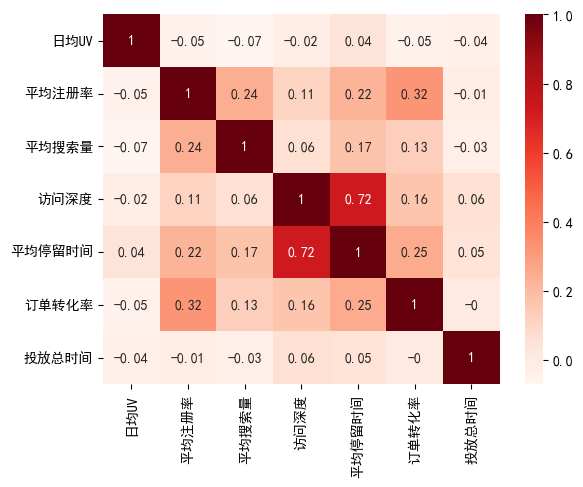

In [18]:
# CorrelationVisualization
import seaborn as sns 
corr = raw_data.corr().round(2)
sns.heatmap(corr,cmap='Reds',annot = True)

We can see ，“” and “time”Correlationcompare，Correlationdescriptionvariablemodelhour，yesEffectivenessyes，can 。

## dataprocessing

data，hourprocessingdata，datathrough 、、、、can Accuracydata。

In [19]:
# 1 time
raw_data2 = raw_data.drop(['time'],axis=1)

variableencoding：

In [20]:
# variable
cols=["","Advertising","","Advertising","Advertising"]
for x in cols:
    data=raw_data2[x].unique()
    print("variable【{0}】：\n{1}".format(x,data))
    print("-·"*20)

variable【】：
['jpg' 'swf' 'gif' 'sp']
-·-·-·-·-·-·-·-·-·-·-·-·-·-·-·-·-·-·-·-·
variable【Advertising】：
['banner' 'tips' '' '' '']
-·-·-·-·-·-·-·-·-·-·-·-·-·-·-·-·-·-·-·-·
variable【】：
['roi' 'cpc' 'cpm' 'cpd']
-·-·-·-·-·-·-·-·-·-·-·-·-·-·-·-·-·-·-·-·
variable【Advertising】：
['140*40' '308*388' '450*300' '600*90' '480*360' '960*126' '900*120'
 '390*270']
-·-·-·-·-·-·-·-·-·-·-·-·-·-·-·-·-·-·-·-·
variable【Advertising】：
['' '' '' 'second' '' '']
-·-·-·-·-·-·-·-·-·-·-·-·-·-·-·-·-·-·-·-·


In [21]:
# classificationencodingprocessing
cols = ['','Advertising','','Advertising','Advertising'] 
model_ohe = OneHotEncoder(sparse=False)  # OneHotEncode
ohe_matrix = model_ohe.fit_transform(raw_data2[cols])  # 
print(ohe_matrix[:2])

[[0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.
  0. 0. 0.]
 [0. 1. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.
  0. 0. 0.]]


C:\Users\Administrator\Envs\jv\lib\site-packages\sklearn\preprocessing\_encoders.py:828: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [22]:
# pandas
ohe_matrix1=pd.get_dummies(raw_data2[cols])
ohe_matrix1.head(5)

,_gif,_jpg,_sp,_swf,Advertising_banner,Advertising_tips,Advertising_,Advertising_,Advertising_,_cpc,...,Advertising_480*360,Advertising_600*90,Advertising_900*120,Advertising_960*126,Advertising_,Advertising_,Advertising_,Advertising_,Advertising_,Advertising_second
0,0,1,0,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,0,1,0,0,1,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
2,0,1,0,0,1,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
3,0,1,0,0,1,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
4,0,1,0,0,1,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0


data：

In [23]:
# Data standardization
sacle_matrix = raw_data2.iloc[:, 1:7]  # 
model_scaler = MinMaxScaler()  # MinMaxScalermodel
data_scaled = model_scaler.fit_transform(sacle_matrix)  # MinMaxScalerprocessing
print(data_scaled.round(2))

[[0.   0.18 0.02 0.01 0.12 0.66]
 [0.01 0.1  0.03 0.01 0.01 0.62]
 [0.   0.06 0.05 0.01 0.01 0.1 ]
 ...
 [0.01 0.01 0.   0.   0.   0.72]
 [0.05 0.   0.   0.   0.   0.31]
 [0.   0.   0.   0.53 0.   0.62]]


dataprocessing，encodingdata and data：

In [24]:
# # 
X = np.hstack((data_scaled, ohe_matrix))

dataprocessing，can modeltraining。

## model


In [25]:
# through K-means Clusteringmodel
score_list = list()  # Kmodel
silhouette_int = -1  # 
for n_clusters in range(2, 8):  # 25
    model_kmeans = KMeans(n_clusters=n_clusters)  # clusteringmodel
    labels_tmp = model_kmeans.fit_predict(X)  # trainingclusteringmodel
    silhouette_tmp = silhouette_score(X, labels_tmp)  # K
    if silhouette_tmp > silhouette_int:  #  if 
        best_k = n_clusters  # saveKK
        silhouette_int = silhouette_tmp  # saveScore
        best_kmeans = model_kmeans  # savemodel
        cluster_labels_k = labels_tmp  # saveclusteringlabel
    score_list.append([n_clusters, silhouette_tmp])  # KScore
print('{:*^60}'.format('K:'))
print(np.array(score_list))  # Kdetailed Score
print('K:{0} \n:{1}'.format(best_k, silhouette_int))

C:\Users\Administrator\Envs\jv\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Administrator\Envs\jv\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Administrator\Envs\jv\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Administrator\Envs\jv\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


*************************K:*************************
[[2.         0.38655493]
 [3.         0.45757883]
 [4.         0.50209812]
 [5.         0.4800359 ]
 [6.         0.47761127]
 [7.         0.48317001]]
K:4 
:0.5020981194788053


C:\Users\Administrator\Envs\jv\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Administrator\Envs\jv\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


（Assessment）yes，。

## clusteringresultfeatureanalysis

through model，（sample）labelclusters，i.e. 4：

In [26]:
# dataclusteringlabel
cluster_labels = pd.DataFrame(cluster_labels_k, columns=['clusters'])  # Training Setlabelinfo
merge_data = pd.concat((raw_data2, cluster_labels), axis=1)  # processingdataclusteringlabel
merge_data.head()

,Channel,dayUV,,,,Order,Placementtime,,Advertising,,Advertising,Advertising,clusters
0,A203,3.69,0.0071,0.0214,2.3071,0.0258,20,jpg,banner,roi,140*40,,1
1,A387,178.70,0.0040,0.0324,2.0489,0.0030,19,jpg,banner,cpc,140*40,,1
2,A388,91.77,0.0022,0.0530,1.8771,0.0026,4,jpg,banner,cpc,140*40,,1
3,A389,1.09,0.0074,0.3382,4.2426,0.0153,10,jpg,banner,cpc,140*40,,1
4,A390,3.37,0.0028,0.1740,2.1934,0.0007,30,jpg,banner,cpc,140*40,,1


，sampleCount and Share：

In [27]:
# calculateclusteringsample and sampleShare
clustering_count = pd.DataFrame(merge_data['Channel'].groupby(merge_data['clusters']).count()).T.rename({'Channel': 'counts'})  # calculateclusteringsample
clustering_ratio = (clustering_count / len(merge_data)).round(2).rename({'counts': 'percentage'})  # calculateclusteringsampleShare
print(clustering_count)
print("#"*30)
print(clustering_ratio)

clusters   0    1    2    3
counts    73  154  313  349
##############################
clusters       0     1     2     3
percentage  0.08  0.17  0.35  0.39


feature：

In [28]:
# calculateclusteringfeature
cluster_features = []  # ，featureinfo
for line in range(best_k):  # 
    label_data = merge_data[merge_data['clusters'] == line]  # data

    part1_data = label_data.iloc[:, 1:7]  # datafeature
    part1_desc = part1_data.describe().round(3)  # featureinfo
    merge_data1 = part1_desc.iloc[2, :]  # feature

    part2_data = label_data.iloc[:, 7:-1]  # datafeature
    part2_desc = part2_data.describe(include='all')  # datafeatureinfo
    merge_data2 = part2_desc.iloc[2, :]  # datafeature

    merge_line = pd.concat((merge_data1, merge_data2), axis=0)  #  and feature
    cluster_features.append(merge_line)  # datafeature

#  featureinfo
cluster_pd = pd.DataFrame(cluster_features).T  # 
print('{:*^60}'.format('main feature:'))
all_cluster_set = pd.concat((clustering_count, clustering_ratio, cluster_pd),axis=0)  # clusteringinfo
all_cluster_set

*************************main feature:*************************


,0,1,2,3
counts,73,154,313,349
percentage,0.08,0.17,0.35,0.39
dayUV,1904.371,2717.419,1390.013,933.015
,0.003,0.005,0.003,0.003
,0.106,0.051,0.152,0.064
,0.943,0.947,1.168,5.916
Order,0.009,0.007,0.017,0.006
Placementtime,8.217,8.529,8.199,8.77
,swf,jpg,swf,jpg
Advertising,tips,banner,,


：

In [29]:
#Data Preprocessing
num_sets = cluster_pd.iloc[:6, :].T.astype(np.float64)  # data
num_sets_max_min = model_scaler.fit_transform(num_sets)  # data
print(num_sets)
print('-'*20)
print(num_sets_max_min)

       dayUV         Order  Placementtime
0  1904.371  0.003  0.106  0.943  0.009  8.217
1  2717.419  0.005  0.051  0.947  0.007  8.529
2  1390.013  0.003  0.152  1.168  0.017  8.199
3   933.015  0.003  0.064  5.916  0.006  8.770
--------------------
[[5.44358789e-01 0.00000000e+00 5.44554455e-01 0.00000000e+00
  2.72727273e-01 3.15236427e-02]
 [1.00000000e+00 1.00000000e+00 0.00000000e+00 8.04343455e-04
  9.09090909e-02 5.77933450e-01]
 [2.56106801e-01 0.00000000e+00 1.00000000e+00 4.52443193e-02
  1.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.28712871e-01 1.00000000e+00
  0.00000000e+00 1.00000000e+00]]


[0.         1.04719755 2.0943951  3.14159265 4.1887902  5.23598776
 0.        ]
['dayUV' '' '' '' 'Order' 'Placementtime']


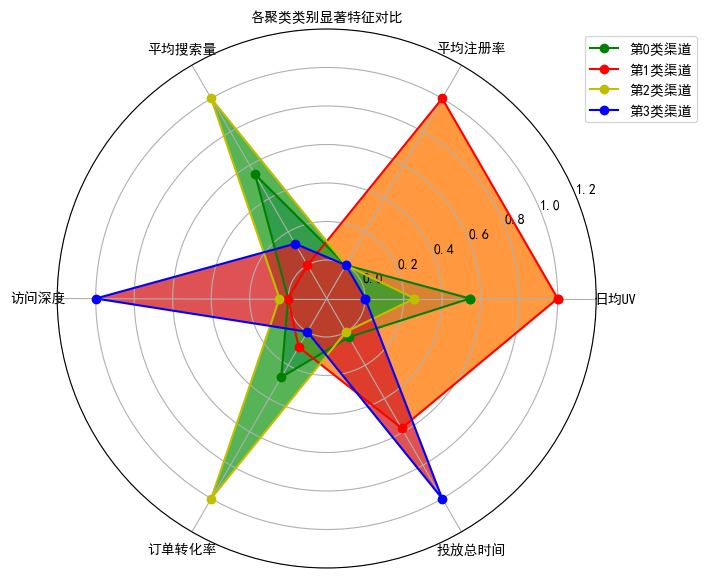

In [31]:
# 
fig = plt.figure(figsize=(7,7))  # 
ax = fig.add_subplot(111, polar=True)  # ，polarparameter
labels = np.array(merge_data1.index)  # datalabel
cor_list = ['g', 'r', 'y', 'b']  # different Color
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False)  # calculate
angles = np.concatenate((angles, [angles[0]]))  # 
# 
for i in range(len(num_sets)):  # 
    data_tmp = num_sets_max_min[i, :]  # data
    data = np.concatenate((data_tmp, [data_tmp[0]]))  # 
    ax.plot(angles, data, 'o-', c=cor_list[i], label="%dChannel"%(i))  # 
    ax.fill(angles, data,alpha=0.8)
    
# Image
print(angles)
print(labels)

ax.set_thetagrids(angles[0:-1] * 180 / np.pi, labels, fontproperties="SimHei")  # 
ax.set_title("clusteringfeature", fontproperties="SimHei")  # 
ax.set_rlim(-0.2, 1.2)  # 
plt.legend(loc="upper right" ,bbox_to_anchor=(1.2,1.0))  # 

## dataConclusion


result，Channelminute4，sampleare:：154、313、349 、73，AnalyzeShareare:：17%、35%、39%、8%。

through can ：

1（2Channel）
Advertising and Placementtime，attribute， therefore AdvertisingEffectiveness，39%， therefore yesChannel。
Placement。



2（1Channel）
Advertising，、dayUV、OrderAdvertisingEffectiveness，yesEffectivenessChannel。
yesdayUVyes，。anduser，Advertisinguser，yesOrder。



3（0Channel）
AdvertisingfeatureyesdayUV and ，“” and “”Effectiveness，can Advertising。
“Advertising”，“”using。



4（3Channel）
Channelfeature， and Count“”。yes，can ChannelPlacementAdvertising。